In [1]:
import xarray as xr
import numpy as np
import os 

#for plotting
import cmocean
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle

path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
# path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

def open_input_datasets():
    
    #open input datasets
    ssp='ssp370'

    psmsl_range   = xr.open_dataset('data/aslc_vs_tr/psmsl_mean_alsc_range.nc').monmean
    sla_ibe_range = xr.open_dataset('data/aslc_vs_tr/allsat_l4_duacs_sla_1993-2023_0.125deg_mean_alsc_range.nc').sla

    tr_at_tgs   = xr.open_dataset('data/aslc_vs_tr/eot20_tr_at_psmsl.nc').tidal_range
    tr_at_duacs = xr.open_dataset('data/aslc_vs_tr/eot20_tr_at_duacs.nc').tidal_range

    hist_range      = xr.open_dataset('data/aslc_vs_tr/hist_aslc_range_memmean_median.nc').zos_ibe
    hist_range_tgs  = xr.open_dataset('data/aslc_vs_tr/hist_aslc_range_memmean_median_tgs.nc').zos_ibe
    hist_range_at_duacs = xr.open_dataset('data/aslc_vs_tr/hist_aslc_range_memmean_median_at_duacs.nc').zos_ibe
    drange          = xr.open_dataset('data/aslc_vs_tr/d_aslc_range_memmean_median_'+ssp+'.nc').zos_ibe
    drange_tgs      = xr.open_dataset('data/aslc_vs_tr/d_aslc_range_memmean_median_'+ssp+'_tgs.nc').zos_ibe
    drange_at_duacs = xr.open_dataset('data/aslc_vs_tr/d_aslc_range_memmean_median_'+ssp+'_at_duacs.nc').zos_ibe

    selected_tgs = ['PAPEETE-B, FARE UTE POINT, SOC.IS.','BARCELONA','SAKAI']#,'FORT-DE-FRANCE II'
    selected_ids = np.array([hist_range_tgs.where(hist_range_tgs.tg==tg,drop=True).id.values[0] for tg in selected_tgs])
    locations = ['Papeete','Barcelona','Sakai']
    countries = ['French Polynesia','Spain','Japan']

    return hist_range_at_duacs, drange_at_duacs, tr_at_duacs, hist_range_tgs, drange_tgs, tr_at_tgs, selected_ids, selected_tgs, locations, countries

hist_range_at_duacs, drange_at_duacs, tr_at_duacs, hist_range_tgs, drange_tgs, tr_at_tgs, selected_ids, selected_tgs, locations, countries = open_input_datasets()

In [2]:
def add_global_map_subplot(fig,da,gs,vmin,vmax,cmap,subplot_title,hatch_condition,add_cbar='below',left_labels=True,cbar_label=None,cbar_extend=None):
    ''' add a subplot with a global map of da to a figure'''
    ax = fig.add_subplot(gs,projection=ccrs.Robinson(central_longitude=0))
    
    p=da.plot(transform=ccrs.PlateCarree(),vmin=vmin,vmax=vmax,cmap=cmap,ax=ax,add_colorbar=False,rasterized=True) #SSLA
    p.set_edgecolor('face')
    if hatch_condition is not None:
        density=7
        ax.contourf(da.lon, da.lat, hatch_condition,transform=ccrs.PlateCarree(),colors='none',levels=[.5,1.5],hatches=[density*'/',density*'/'])

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,linewidth=1, color='lightgrey', alpha=0, linestyle='-')
    gl.top_labels = gl.right_labels = False #don't label top and right axes
    gl.left_labels = left_labels
        
    gl.xlabel_style = {'color': 'black','rotation':0}
    gl.ylabel_style = {'color': 'black','rotation':0}
                                                                   
    ax.coastlines(resolution='50m',color='black')
    ax.set_title(subplot_title)
    ax.set_extent([-180,180,-65,65], crs=ccrs.PlateCarree())

    if add_cbar=='below':
        cax=inset_axes(ax,width="100%", height="100%",bbox_to_anchor=(.1, -.25,.8,.1),bbox_transform=ax.transAxes)
        fig.colorbar(p, cax=cax,orientation='horizontal',label=cbar_label,extend=cbar_extend)
    elif add_cbar =='right':
        cax=inset_axes(ax,width="100%", height="100%",bbox_to_anchor=(1.05, .025,.04,.95),bbox_transform=ax.transAxes)
        fig.colorbar(p, cax=cax,orientation='vertical',label=cbar_label,extend=cbar_extend)
    return fig,ax

def figure_2c(fig, gs):

    # hist_range_at_duacs, _, tr_at_duacs, hist_range_tgs, _, tr_at_tgs, _, _, _, _ = open_input_datasets()

    #(c) plot historical ASLC range divided by tidal range
    amp_discrete = matplotlib.colors.LinearSegmentedColormap.from_list('Custom cmap',  [cmocean.cm.amp(i) for i in range(cmocean.cm.amp.N)], 16) #define discrete colormap

    fig, ax = add_global_map_subplot(fig, hist_range_at_duacs/tr_at_duacs,
                                     gs, 0,.8, amp_discrete,'Historical', None, 'below',True, 'ASLC range / Tidal range [-]', 'max')
    ax.scatter(hist_range_tgs.lon, hist_range_tgs.lat, c = hist_range_tgs/tr_at_tgs,
               vmin = 0, vmax = .8, cmap = amp_discrete, edgecolor = 'black', s = 25, marker = 'o', transform = ccrs.PlateCarree(), zorder = 5)
    ax.set_facecolor("grey")

def figure_2d(fig, gs):

    # _, drange_at_duacs, tr_at_duacs, hist_range_tgs, drange_tgs, tr_at_tgs, selected_ids, selected_tgs, locations, countries = open_input_datasets()

    #(d) plot projected ASLC range change divided by tidal range
    balance_discrete = matplotlib.colors.LinearSegmentedColormap.from_list('Custom cmap',  [cmocean.cm.balance(i) for i in range(cmocean.cm.balance.N)], 16)

    fig,ax = add_global_map_subplot(fig,drange_at_duacs/tr_at_duacs,
                                    gs,-.2,.2,balance_discrete,'Future change (SSP3-7.0)',None,'below',False,'ASLC range change / Tidal range [-]','max')
    s1=ax.scatter(hist_range_tgs.lon,hist_range_tgs.lat,c=drange_tgs/tr_at_tgs,
                vmin=-.2,vmax=.2,cmap=balance_discrete,edgecolor='black',s=25,marker='o',transform=ccrs.PlateCarree(),zorder=5)

    ax.set_facecolor("grey")

    #draw rectangles around regions of large changes relative to the tidal range
    ax.plot([-4, 38, 38, -4, -4], [28, 28, 49, 49, 28],
            color='black', linewidth=1.5,linestyle='dashed',
            transform=ccrs.PlateCarree(),zorder=8, #remove this line to get straight lines
            )

    ax.plot([-167, -132, -132, -167, -167], [-30, -30, -5, -5, -30],
            color='black', linewidth=1.5,linestyle='dashed',
            transform=ccrs.PlateCarree(),zorder=8, #remove this line to get straight lines
            )

    ax.plot([-179, -160, -160, -179, -179], [12, 12, 36, 36, 12],
            color='black', linewidth=1.5,linestyle='dashed',
            transform=ccrs.PlateCarree(),zorder=8, #remove this line to get straight lines
            )

    ax.plot([123, 147, 147, 123, 123], [29, 29, 49, 49, 29],
            color='black', linewidth=1.5,linestyle='dashed',
            transform=ccrs.PlateCarree(),zorder=8, #remove this line to get straight lines
            )
    '''
    #highlight selected locations
    ax.scatter(hist_range_tgs.lon.sel(id=selected_ids),hist_range_tgs.lat.sel(id=selected_ids),c=(drange_tgs/tr_at_tgs).sel(id=selected_ids),
                vmin=-.2,vmax=.2,cmap=balance_discrete,edgecolor='black',s=50,marker='o',transform=ccrs.PlateCarree(),zorder=11)

    for t,tg in enumerate(selected_tgs):
        ax.annotate(locations[t]+'\n'+'('+countries[t]+')', xy=([.085,.505,.85][t], [.35,.83,.775][t]), 
                    xytext=([.095,.53,.96][t], [.1,.58,.72][t]),arrowprops=dict(arrowstyle="->", connectionstyle="arc3"),
                    xycoords='axes fraction',textcoords='axes fraction',ha='center',fontweight='bold',zorder=12)
    '''

In [3]:
def figure_2a(fig, gs):

    def plot_timeseries(ax, amplitude_annual_cycle):

        def find_events(x):
            x = x.astype(int)
            x = np.pad(x, ((1,1)), constant_values = 0)

            # Find change points
            changes = np.diff(x)

            start = np.where(changes ==  1)[0]
            end   = np.where(changes == -1)[0]

            return start, end
        
        dt, n_years = 5/60, 1.5
        elevation = np.arange(-3,3,0.01)

        _, waterlevel, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = amplitude_annual_cycle, mean_waterlevel = 0., dt = dt, n_years = n_years)
        tidal_cycle, low_waterlevel, high_waterlevel = f.calculate_highlow_water(waterlevel, plot = False)   
        time = 365*tidal_cycle/705     
        ax.plot(time, low_waterlevel, c = 'blue', alpha = 0.6, label = 'High water level')
        ax.plot(time, high_waterlevel, c = 'orange', alpha = 0.6, label = 'Low water level')
        ax.fill_between(time, low_waterlevel, high_waterlevel, color = (0,0,1,0.1))

        for z in [-0.5,-0.12,0.12,0.5]:

            start, end = find_events(high_waterlevel < z)
            if start.size > 0:
                duration = end - start
                ax.plot([time[start[np.argmax(duration)]], time[end[np.argmax(duration)]-1]], [z, z], c = (1,0.5,0,0.7), lw = 5)
                for i in range(start.size):
                    ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.5))

            start, end = find_events(low_waterlevel > z)
            if start.size > 0:
                duration = end - start
                ax.plot([time[start[np.argmax(duration)]], time[end[np.argmax(duration)]-1]], [z, z], c = (0,0,1,0.7), lw = 5)
                for i in range(start.size):
                    ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.5))

            start, end = find_events((low_waterlevel < z) & (high_waterlevel > z))
            if start.size > 0:
                for i in range(start.size):
                    ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.2), linestyle = 'dotted')

            # if (amplitude_annual_cycle == 0) & ((z == -0.12) | (z == 0.12)):
            #     r = np.random.choice(time.size, size = 1)
            #     ax.plot([time[r],time[r+2]], [z,z], lw = 3, c = (0,0,0,0.5))

                
        # ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
        ax.set_xlabel('Time [days]', fontsize = 12)
        ax.set_yticks(ticks = [-1, -0.5, 0, 0.5, 1])
        ax.set_xlim(0, 365*1.5)
        ax.set_ylim(-1.5, 1.5)

    def add_annotations(ax0, ax1):

        #annotate longest events
        #upper half
        ann = ax0.annotate("Longest emergence",
                        xy=(0.53, 0.68), xycoords='axes fraction',
                        xytext=(0.44, 0.9), textcoords='axes fraction',
                        size=12, va="center", ha="center",
                        arrowprops=dict(arrowstyle="-|>",
                                        connectionstyle="arc3,rad=-0.2",
                                        fc="w")),
        ann = ax0.annotate("Longest inundation",
                        xy=(0.83, 0.32), xycoords='axes fraction',
                        xytext=(0.75, 0.08), textcoords='axes fraction',
                        size=12, va="center", ha="center",
                        arrowprops=dict(arrowstyle="-|>",
                                        connectionstyle="arc3,rad=0.2",
                                        fc="w")),
        ax0.text(.01,.18,'Low water',transform=ax0.transAxes,color='blue')
        ax0.text(.82,.775,'High water',transform=ax0.transAxes,color='darkorange')

        #lower half
        ann = ax1.annotate("Longest emergence",
                        xy=(0.32, 0.69), xycoords='axes fraction',
                        xytext=(0.22, 0.9), textcoords='axes fraction',
                        size=12, va="center", ha="center",
                        arrowprops=dict(arrowstyle="-|>",
                                        connectionstyle="arc3,rad=-0.2",
                                        fc="w"))
        ann = ax1.annotate("Longest inundation",
                        xy=(0.7, 0.3), xycoords='axes fraction',
                        xytext=(0.6, 0.1), textcoords='axes fraction',
                        size=12, va="center", ha="center",
                        arrowprops=dict(arrowstyle="-|>",
                                        connectionstyle="arc3,rad=0.2",
                                        fc="w"))
    
        ax1.text(.01,.18,'Low water',transform=ax1.transAxes,color='blue')
        ax1.text(.82,.775,'High water',transform=ax1.transAxes,color='darkorange')

    np.random.seed(12345)

    rows, cols = 2, 1
    gs_2a = gs.subgridspec(rows, cols, hspace = .0, wspace = .15)
    ax0 = fig.add_subplot(gs_2a[0,0])
    ax1 = fig.add_subplot(gs_2a[1,0])

    plot_timeseries(ax0, amplitude_annual_cycle = 0.0)
    ax0.set_xticks([])
    ax0.text(x = 365*1.47, y = 1.15, s = 'ASLC/TR = 0.0', horizontalalignment = 'right')
    ax0.spines['bottom'].set_visible(False)

    plot_timeseries(ax1, amplitude_annual_cycle = 0.5)
    ax1.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax1.yaxis.set_label_coords(-0.1,1)
    ax1.text(x = 365*1.47, y = 1.15, s = 'ASLC/TR = 0.5', horizontalalignment = 'right')
    # ax0.spines['top'].set_visible(False)

    add_annotations(ax0, ax1)

def figure_2b(fig, gs, path_bin):
    
    def blend_arrays(array0, array1, xmin, xmax):

        array0, array1 = np.log10(array0), np.log10(array1)
        
        # Normalize arrays between 0 and 1
        a0 = (array0 - xmin) / (xmax - xmin)
        a1 = (array1 - xmin) / (xmax - xmin)
        a0[np.isnan(a0)] = 0
        a1[np.isnan(a1)] = 0 
        a0[a0 > 1] = 1
        a1[a1 > 1] = 1 
        a0[a0 < 0] = 0
        a1[a1 < 0] = 0 

        # Create RGB image: R from array1, B from array0, G optional
        rgb = np.ones((array0.shape[0], array0.shape[1], 3))
        rgb[..., 0] -= a0   # Red channel = array1
        rgb[..., 1] -= (a0 + a1*0.5)   # Green channel = array1
        rgb[..., 2] -= a1   # Blue channel = array0

        # # Create RGB image: R from array1, B from array0, G optional
        # rgb = np.ones((array0.shape[0], array0.shape[1], 3))
        # rgb[..., 1] -= a1*0.5   # Green channel = array1
        # rgb[..., 2] -= a1   # Blue channel = array0

        # # Create RGB image: R from array1, B from array0, G optional
        # rgb = np.ones((array0.shape[0], array0.shape[1], 3))
        # rgb[..., 0] -= a0   # Red channel = array1
        # rgb[..., 1] -= a0   # Green channel = array1

        return rgb

    def add_zone_boundaries(ax, path_bin):

        z, aslc, inund_max, emerg_max = np.load(path_bin)
        ntrials = aslc.shape[1]

        tidal, spring_neap, annual = 12.25/24, 29.6, 365.25

        sn_inund_boundary = np.argmin(inund_max < tidal, axis = 0)
        annual_inund_boundary = np.argmin(inund_max < spring_neap, axis = 0)
        annual_emerg_boundary = np.argmax(emerg_max < spring_neap, axis = 0) - 1
        sn_emerg_boundary = np.argmax(emerg_max < tidal, axis = 0) - 2

        start, end = 0, ntrials - 1

        ax.plot([start, end], [sn_inund_boundary[start],sn_inund_boundary[end]], c = (1,1,1,0.5), lw = 0.5)
        ax.plot([start, end], [annual_inund_boundary[start],annual_inund_boundary[end]], c = (1,1,1,0.5), lw = 0.5)
        ax.plot([start, end], [sn_emerg_boundary[start],sn_emerg_boundary[end]], c = (1,1,1,0.5), lw = 0.5)
        ax.plot([start, end], [annual_emerg_boundary[start],annual_emerg_boundary[end]], c = (1,1,1,0.5), lw = 0.5)

    def add_colorbars(xmin, xmax):

        # Create custom colorbars
        white = (1, 1, 1, 0)
        blue = (0, 0, 1, 1)
        orange = (1., 0.5, 0., 1)
        cmap0 = LinearSegmentedColormap.from_list("white_to_blue", [white, blue])
        cmap1 = LinearSegmentedColormap.from_list("white_to_orange", [white, orange])
        norm = plt.Normalize(vmin = xmin, vmax = xmax)
        mappable_inund = ScalarMappable(norm = norm, cmap = cmap0)
        mappable_emerg = ScalarMappable(norm = norm, cmap = cmap1) 

        # Add colorbars using dummy mappables
        cbar0 = fig.colorbar(mappable_inund, ax = ax)
        cbar0.ax.set_ylabel('Avg. annual maximum duration', fontsize=12)
        cbar0.ax.set_yticks(ticks = [np.log10(1/24),np.log10(1),np.log10(30),np.log10(365.25)], labels = ['hour','day', 'month', 'year'], fontsize = 9)
        cbar0.ax.tick_params(axis = 'y', labelrotation = 90)
        cbar0.ax.set_title('         Inundation', fontsize = 12)

        pos = cbar0.ax.get_position()
        new_pos = [pos.x0 - 0.015, pos.y0, pos.width, pos.height]
        cbar0.ax.set_position(new_pos)

        cbar1 = fig.colorbar(mappable_emerg, ax=ax)
        cbar1.ax.set_yticks(ticks = [])
        cbar1.ax.tick_params(axis = 'y', labelrotation = 90)
        cbar1.ax.set_title('Emergence            ', fontsize = 12)
        
        pos = cbar1.ax.get_position()
        new_pos = [pos.x0 + 0.015, pos.y0, pos.width, pos.height]
        cbar1.ax.set_position(new_pos)

        return cbar0, cbar1

    def add_inund_colorbar_historgram(cbar, x, xmin, xmax, axis_coords, ):
        
        # Create a new Axes next to the colorbar for histogram
        # [left, bottom, width, height] in figure coordinates (0-1 range)
        hist_ax0 = fig.add_axes(axis_coords)  # adjust position as needed

        bins = np.linspace(xmin, xmax, 100)
        density, bins = np.histogram(np.log10(x), bins = bins, density = True)
        density = density/density.max()

        for x0, x1, y in zip(bins[:-1], bins[1:], density):
            
            a1 = (x1 - xmin) / (xmax - xmin)
            rect = Rectangle((0, x0), y, x1 - x0, transform = hist_ax0.transData, facecolor = (1 - a1,1 - a1,1,1), edgecolor = (0,0,0,1), lw = 0.5)
            hist_ax0.add_patch(rect)

        # Clean up histogram axes
        hist_ax0.set_xlim(0, 1)
        hist_ax0.set_ylim(cbar.ax.get_ylim()) 
        hist_ax0.set_xticks([])
        hist_ax0.set_yticks([])
        hist_ax0.invert_xaxis()
        for spine in hist_ax0.spines.values():
            spine.set_visible(False)

    def add_emerg_colorbar_historgram(cbar, x, xmin, xmax, axis_coords):
        
        # Create a new Axes next to the colorbar for histogram
        hist_ax1 = fig.add_axes(axis_coords)

        bins = np.linspace(xmin, xmax, 100)
        density, bins = np.histogram(np.log10(x), bins = bins, density = True)
        density = density/density.max()

        for x0, x1, y in zip(bins[:-1], bins[1:], density):
            
            a1 = (x1 - xmin) / (xmax - xmin)
            rect = Rectangle((0, x0), y, x1 - x0, transform=hist_ax1.transData, facecolor = (1,1 - a1*0.5,1 - a1,1), edgecolor = (0,0,0,1), lw = 0.5)
            hist_ax1.add_patch(rect)

        hist_ax1.text(x = 1.4, y = np.log10(6.125/24), s = 'Tidal', rotation = 90, fontsize = 9, verticalalignment = 'center', horizontalalignment = 'center')
        hist_ax1.text(x = 1.4, y = np.log10(14.8/2), s = 'Spring-neap', rotation = 90, fontsize = 9, verticalalignment = 'center', horizontalalignment = 'center')
        hist_ax1.text(x = 1.4, y = np.log10(365.25/2), s = 'Annual', rotation = 90, fontsize = 9, verticalalignment = 'center', horizontalalignment = 'center')

        # Clean up histogram axes
        hist_ax1.set_xlim(0, 1)
        hist_ax1.set_ylim(cbar.ax.get_ylim())
        hist_ax1.set_xticks([])
        hist_ax1.set_yticks([])
        hist_ax1.invert_xaxis()
        for spine in hist_ax1.spines.values():
            spine.set_visible(False)

    # Load data and deal with logged 0's and nans
    z, aslc, inund_max, emerg_max = np.load(path_bin)
    subset = np.isnan(inund_max) | np.isnan(emerg_max) | (inund_max == 0) | (emerg_max == 0)
    inund_max[subset] = np.nan
    emerg_max[subset] = np.nan

    xmin, xmax = np.log10(1/24), np.log10(365.25*1.4)

    ax = fig.add_subplot(gs)
    rgb = blend_arrays(inund_max, emerg_max, xmin, xmax)
    im = ax.imshow(rgb, vmin = xmin, vmax = xmax)
    add_zone_boundaries(ax, path_bin)

    #cbar0, cbar1 = add_colorbars(xmin, xmax)

    #add_inund_colorbar_historgram(cbar0, inund_max, xmin, xmax, axis_coords = [0.8155, 0.5135, 0.015, 0.367])
    #add_emerg_colorbar_historgram(cbar1, emerg_max, xmin, xmax, axis_coords = [0.7825, 0.5135, 0.015, 0.367])

    ax.set_xlabel('ASLC Range / Tidal Range [-]', fontsize = 12)
    ax.set_ylabel('Deviation from MSL / Tidal Range [-]', fontsize = 12)
    ax.set_xticks(ticks = [0, 25, 50, 75, 99], labels = [0, 0.5, 1, 1.5, 2])
    ax.set_yticks(ticks = [0, 25, 50, 75, 99], labels = [2, 1, 0, -1, -2])

    ax.text(40, 15, s = 'Supratidal',  rotation =  13, c = 'k', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(48, 33, s = '(3)',      rotation = 0, c = 'w', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(43, 50, s = '(5)',      rotation = 0, c = 'w', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(88, 50, s = '(9)',      rotation = 0, c = 'w', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 8, 41, s = '(2)', rotation = 0, c = 'w', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 80, 41, s = '(6)', rotation = 0, c = 'w', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 80, 58, s = '(8)', rotation = 0, c = 'w', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 2, 50, s = '(1)',       rotation =   0, c = 'w', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 8, 58, s = '(4)', rotation =  0, c = 'w', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(48, 66, s = '(7)',      rotation =  0, c = 'w', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(40, 85, s = 'Subtidal',    rotation =  -13, c = 'k', alpha = 1, verticalalignment = 'center', fontsize = 10, zorder = 1)
    return ax

In [4]:
def blend_arrays(array0, array1, xmin, xmax):

    array0, array1 = np.log10(array0), np.log10(array1)
    
    # Normalize arrays between 0 and 1
    a0 = (array0 - xmin) / (xmax - xmin)
    a1 = (array1 - xmin) / (xmax - xmin)
    a0[np.isnan(a0)] = 0
    a1[np.isnan(a1)] = 0 
    a0[a0 > 1] = 1
    a1[a1 > 1] = 1 
    a0[a0 < 0] = 0
    a1[a1 < 0] = 0 

    # Create RGB image: R from array1, B from array0, G optional
    rgb = np.ones((array0.shape[0], array0.shape[1], 3))
    rgb[..., 0] -= a0   # Red channel = array1
    rgb[..., 1] -= (a0 + a1*0.5)   # Green channel = array1
    rgb[..., 2] -= a1   # Blue channel = array0

    # # Create RGB image: R from array1, B from array0, G optional
    # rgb = np.ones((array0.shape[0], array0.shape[1], 3))
    # rgb[..., 1] -= a1*0.5   # Green channel = array1
    # rgb[..., 2] -= a1   # Blue channel = array0

    # # Create RGB image: R from array1, B from array0, G optional
    # rgb = np.ones((array0.shape[0], array0.shape[1], 3))
    # rgb[..., 0] -= a0   # Red channel = array1
    # rgb[..., 1] -= a0   # Green channel = array1

    return rgb
    
def add_array_colorbar(fig,ax):
    xmin, xmax = np.log10(1/24), np.log10(365.25*1.4)

    # Add inundation and emergence colorbars
    white = (1, 1, 1, 0)
    blue = (0, 0, 1, 1)
    orange = (1., 0.5, 0., 1)
    cmap0 = LinearSegmentedColormap.from_list("white_to_blue", [white, blue])
    cmap1 = LinearSegmentedColormap.from_list("white_to_orange", [white, orange])
    norm = plt.Normalize(vmin = xmin, vmax = xmax)
    mappable_inund = ScalarMappable(norm = norm, cmap = cmap0)
    mappable_emerg = ScalarMappable(norm = norm, cmap = cmap1) 
    
    cax0=ax.inset_axes([-0.1,0,.1,1],transform=ax.transAxes) #create axes for both colorbars
    cax1=ax.inset_axes([0,-0.1,1,.1],transform=ax.transAxes)
    
    cbar0 = fig.colorbar(mappable_inund, cax = cax0,orientation='vertical')
    cbar0.ax.set_ylabel('Inundation', fontsize=10)
    cbar0.ax.set_yticks(ticks = [np.log10(1/24),np.log10(1),np.log10(30),np.log10(365.25)], labels = ['hour','day', 'month', 'year'], fontsize = 9)
    cbar0.ax.tick_params(axis = 'y', labelrotation = 90)
    cbar0.ax.yaxis.tick_left()
    cbar0.ax.yaxis.set_label_position("left")
    
    cbar1 = fig.colorbar(mappable_emerg, cax=cax1,orientation='horizontal')
    cbar1.ax.set_xticks(ticks = [np.log10(1/24),np.log10(1),np.log10(30),np.log10(365.25)], labels = ['hour','day', 'month', 'year'], fontsize = 9)
    cbar1.ax.tick_params(axis = 'y', labelrotation = 90)
    cbar1.ax.set_xlabel('Emergence', fontsize=10)

    daily = 12.25/24
    spr_neap = 29.6

    #Add combined array
    nx, ny = 1000, 1000
    max_inundation_duration = np.tile(10**np.linspace(xmin, xmax, nx), reps = ny).reshape(ny,nx).T
    max_emergent_duration = np.tile(10**np.linspace(xmin, xmax, ny), reps = nx).reshape(nx,ny)
    rgb = blend_arrays(max_inundation_duration, max_emergent_duration, xmin, xmax)
    ax.imshow(rgb, vmin = xmin, vmax = xmax)
    
    ax.set_title('Average annual''\n''maximum duration')
    ax.invert_yaxis()
    ax.set_yticks([],[])
    ax.set_xticks([],[])

    i_daily = np.argmin(np.abs((daily)-max_inundation_duration[:,0])) #find demarcations in array
    i_sn = np.argmin(np.abs((spr_neap)-max_inundation_duration[:,0]))

    for i in [i_daily,i_sn]: #plot demarcations of domains
        ax.axhline(y=i,color='k',linestyle='dashed',alpha=1,lw=1)
        ax.axvline(x=i,color='k',linestyle='dashed',alpha=1,lw=1)

    #annotate domains in colorbars
    cax1.text(.13,-.065,'Tidal',transform=ax.transAxes,color='black',fontsize=10,ha='center')
    cax1.text(.48,-.065,'Spr-Neap',transform=ax.transAxes,color='black',fontsize=10,ha='center')
    cax1.text(.85,-.065,'Annual',transform=ax.transAxes,color='black',fontsize=10,ha='center')
    
    cax0.text(-.045,.06,'Tidal',transform=ax.transAxes,color='black',fontsize=10,ha='center',rotation=90)
    cax0.text(-.045,.34,'Spr-Neap',transform=ax.transAxes,color='black',fontsize=10,ha='center',rotation=90)
    cax0.text(-.045,.74,'Annual',transform=ax.transAxes,color='black',fontsize=10,ha='center',rotation=90)
    
    #annotate domains in array
    x_coords = [.13,.49,.85]
    y_coords = [.13,.48,.83]
    for j in np.arange(9):
        ax.text(x_coords[np.mod(j,3)],y_coords[np.floor_divide(j,3)],'('+str(j+1)+')',transform=ax.transAxes,color='w',fontsize=10,ha='center',va='center')
        
    cax0.axhline(y=np.log10(daily),color='black',linestyle='dashed',lw=1)
    cax0.axhline(y=np.log10(spr_neap),color='black',linestyle='dashed',lw=1)
    cax1.axvline(x=np.log10(daily),color='black',linestyle='dashed',lw=1)
    cax1.axvline(x=np.log10(spr_neap),color='black',linestyle='dashed',lw=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.26816575713932655..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5..1.0].


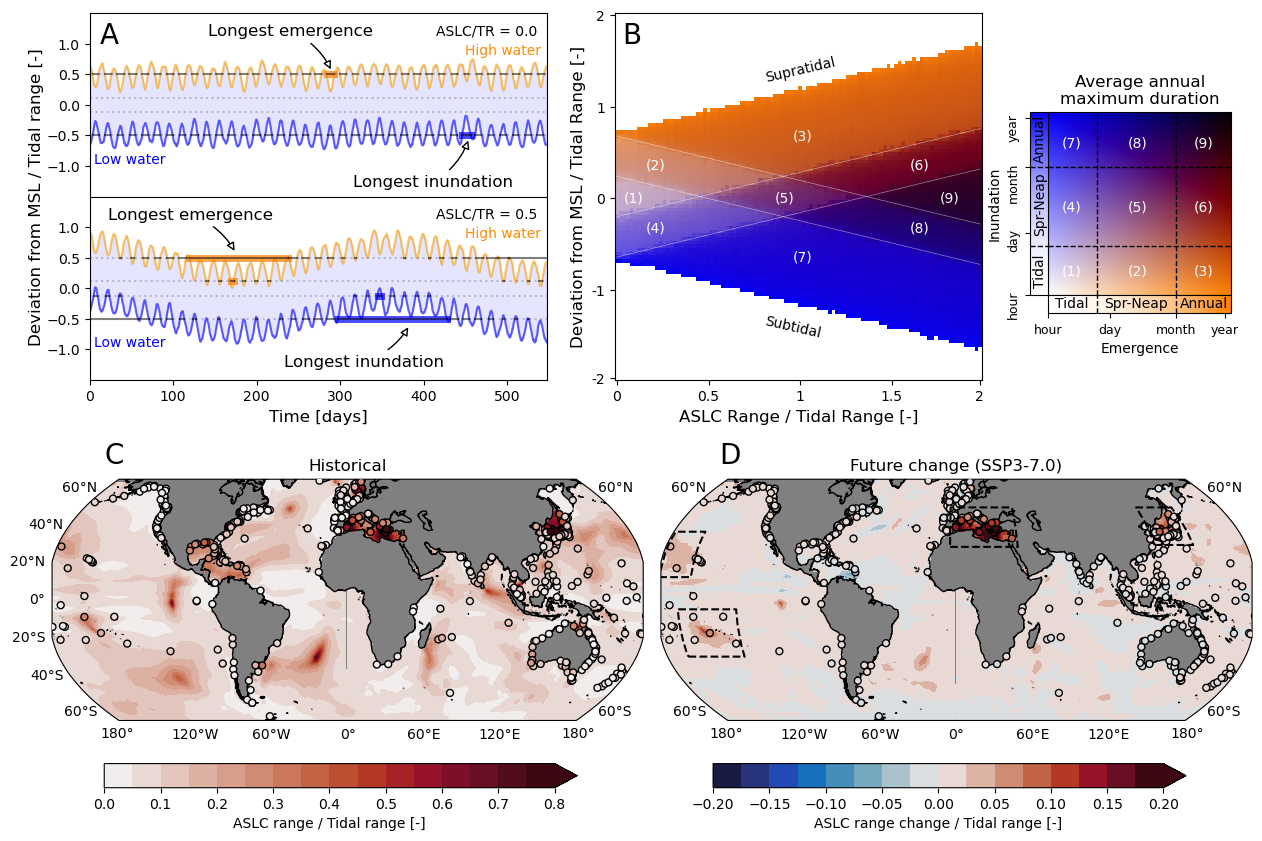

In [14]:
def figure_2_multipanel(path_png):

    rows, cols = 2, 2
    fig = plt.figure(figsize=(15,10))
    gs_top = fig.add_gridspec(rows, cols, hspace = .1, wspace = .05,right=.75) #define subplot grid
    gs_bottom = fig.add_gridspec(rows, cols, hspace = .1, wspace = .03,left=.1)
    
    figure_2a(fig, gs_top[0,0])
    ax = figure_2b(fig, gs_top[0,1], path_bin = './bin/figure_2/figure_2b-alt.npy')
    
    ax=inset_axes(ax,width="100%", height="100%",bbox_to_anchor=(1.2, .25,.5,.5),bbox_transform=ax.transAxes) #add array colorbar to 2b
    add_array_colorbar(fig,ax)
    
    figure_2c(fig, gs_bottom[1,0])
    figure_2d(fig, gs_bottom[1,1])
    
    fig.text(x = 0.132, y = 0.85, s = 'A', fontsize = 20)
    fig.text(x = 0.48, y = 0.85, s = 'B', fontsize = 20)
    fig.text(x = 0.135, y = 0.43, s = 'C', fontsize = 20)
    fig.text(x = 0.545, y = 0.43, s = 'D', fontsize = 20)

    if path_png is not None:
        plt.savefig(path_png, dpi = 300, bbox_inches = "tight", format='png')
    plt.show()

figure_2_multipanel(path_png = './figures/figure_2/figure_2.png')